In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn.objects as so
import os
import sys
import scipy
import pandas
import math

notebook_dir = os.getcwd()
project_root_dir = os.path.dirname(notebook_dir) # This should resolve to /path/to/project_root/
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

import h5py
import numpy as np
from dataset import load_dataset
from config import DatasetConfig

In [2]:
dataset = load_dataset(DatasetConfig(db_file="../dataset/HGF-20p.h5", label="HGF"))

In [3]:
# Representative Data
datasetX = dataset.trainX.numpy()
datasetY = dataset.trainY.numpy()
# Position
x0 = datasetX[:,0]
x1 = datasetX[:,1]
# Volume Derivative
dvdx0 = datasetX[:,24]
# Velocity
xd0 = datasetX[:,48]
yd0 = datasetX[:,56]
zd0 = datasetX[:,64]
# Coeff
coeff = datasetX[:,72]
# Volume
determ = datasetX[:,73]
# force
fx = datasetY[:,0]
fy = datasetY[:,8]
fz = datasetY[:,23]

In [6]:
# Baseline error with smoothl1 loss
import torch.nn as nn
import torch
l = datasetY.shape[0]
print("SmoothL1", nn.functional.smooth_l1_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)
print("L1", nn.functional.l1_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)
print("L2", nn.functional.mse_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)

/tmp/ipykernel_1872283/955144348.py:5: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([4026240, 24])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("SmoothL1", nn.functional.smooth_l1_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)


SmoothL1 0.02112746571166812


/tmp/ipykernel_1872283/955144348.py:6: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([4026240, 24])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("L1", nn.functional.l1_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)


L1 0.05582979975914237


/tmp/ipykernel_1872283/955144348.py:7: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([4026240, 24])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  print("L2", nn.functional.mse_loss(torch.tensor(datasetY), torch.tensor(0), reduction='sum').item() / l)


L2 0.5941798368285226


In [10]:
data = [
    {"name": "Position x0", "value":x0},
    {"name": "Position x1", "value":x1},
    {"name": "Volume Derivative dvdx0", "value":dvdx0,  "log":False},
    {"name": "Velocity xd0", "value":xd0, "log":True},
    {"name": "Velocity yd0", "value":yd0, "log":True},
    {"name": "Velocity zd0", "value":zd0, "log":True},
    {"name": "Coefficient coeff", "value":coeff},
    {"name": "Volume determ", "value":determ},
    {"name": "Force fx", "value":fx, "log":True},
    {"name": "Force fy", "value":fy, "log":True},
    {"name":  "Force fz", "value":fz, "log":True}
]


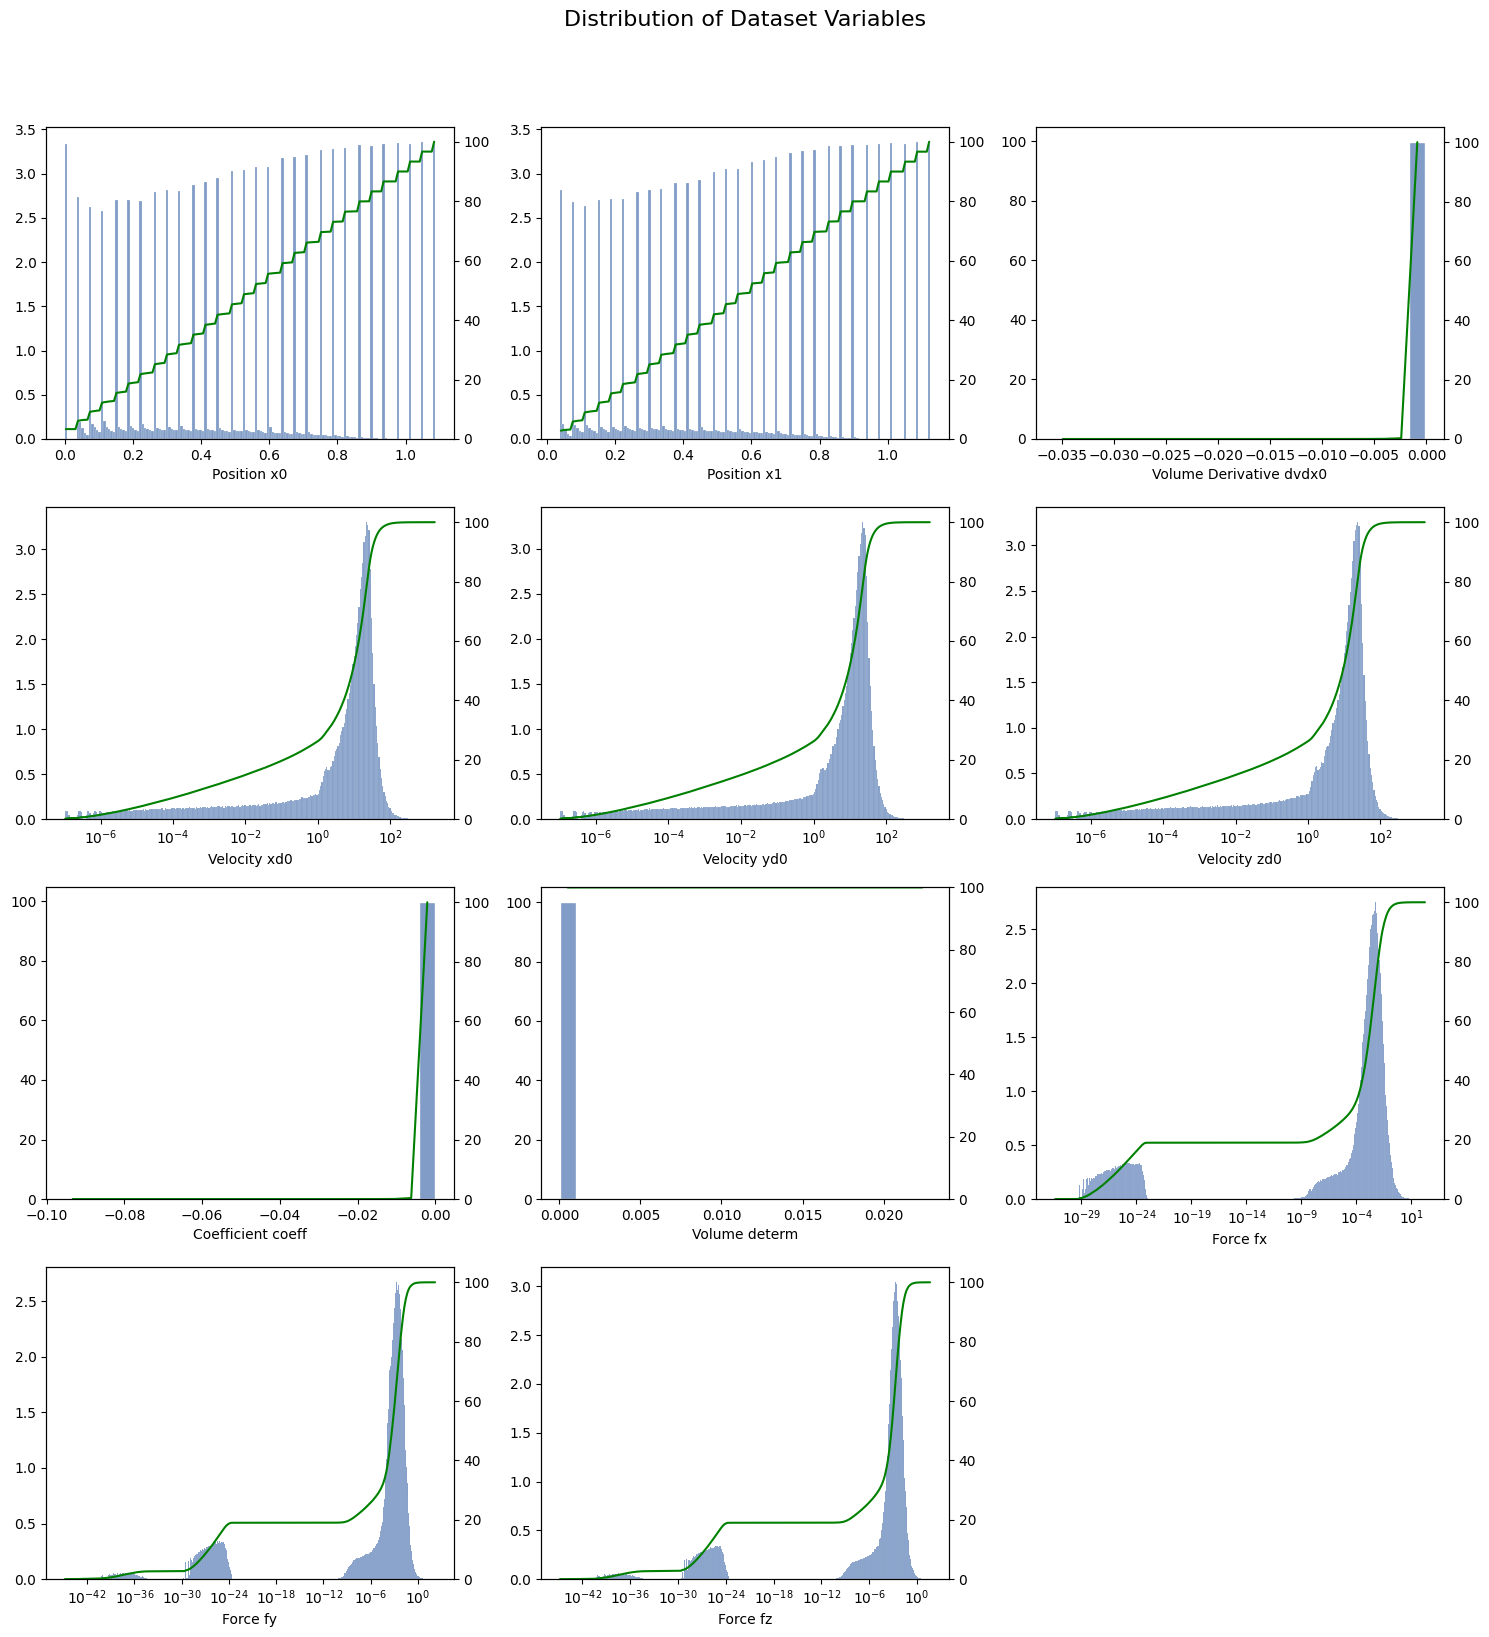

In [11]:
num_variables = len(data)
num_cols = 3
num_rows = math.ceil(num_variables / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False)
axes_flat = axes.flatten() # Flatten the 2D array of axes for easy iteration

# --- 5. Iterate Through Variables and Plot on Subplots ---
def plot(i, var_name, values, bins="auto", log=False):
    ax = axes_flat[i]

    plot_instance1 = (
        so.Plot(x=np.abs(values) if log else values)
        .on(ax) # Attach this plot to ax1
        .add(so.Bars(), so.Hist(bins=bins, stat='percent'))
    )

    ax2 = ax.twinx()
    plot_instance2 = (
        so.Plot(x=np.abs(values) if log else values)
        .on(ax2) # Attach this plot to ax1
        .add(so.Line(color='green'), so.Hist(bins=bins, stat='percent', cumulative=True))
        .limit(y=(0, None))
    )

    if log:
        plot_instance1 = plot_instance1.scale(x='log')
        plot_instance2 = plot_instance2.scale(x='log')

    plot_instance1.plot()
    plot_instance2.plot()

    ax2.yaxis.tick_right()
    ax.set_xlabel(var_name)

for (i, d) in enumerate(data):
    plot(i, d["name"], d["value"], log=d.get("log"), bins=d.get("bins") or "auto")
for j in range(num_variables, len(axes_flat)):
    fig.delaxes(axes_flat[j])

fig.tight_layout()
fig.suptitle("Distribution of Dataset Variables", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.savefig("distribution.svg")

In [8]:
print(f"Variable                  =     Mean (+/-  Std. Dev) [    Minimum,       Maximum]")
print("-" * 81)
for d in data:
    v = d["value"]
    print(f"{d["name"]:25} = {np.mean(v):+.5f} (+/- {np.std(v):9.6f}) [{np.min(v):12.6f}, {np.max(v):12.6f}]")

print(f"Total Datapoints: {data[0]['value'].size}")

Variable                  =     Mean (+/-  Std. Dev) [    Minimum,       Maximum]
---------------------------------------------------------------------------------
Position x0               = +0.55122 (+/-  0.321395) [    0.000000,     1.087500]
Position x1               = +0.58872 (+/-  0.320561) [    0.037500,     1.125000]
Volume Derivative dvdx0   = -0.00037 (+/-  0.000210) [   -0.035729,    -0.000092]
Velocity xd0              = +2.23064 (+/-  9.514277) [    0.000000,  1793.573730]
Velocity yd0              = +2.23031 (+/-  9.435901) [    0.000000,  1658.369141]
Velocity zd0              = +2.22919 (+/-  9.504348) [    0.000000,  1766.545776]
Coefficient coeff         = -0.00019 (+/-  0.000680) [   -0.095366,    -0.000000]
Volume determ             = +0.00005 (+/-  0.000077) [    0.000011,     0.022889]
Force fx                  = +0.00009 (+/-  0.248011) [ -188.010498,   164.036346]
Force fy                  = -0.00033 (+/-  0.146150) [ -160.864349,    51.293491]
Force fz        